In [2]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from statsmodels.miscmodels.ordinal_model import OrderedModel
import matplotlib.pyplot as plt
import numpy as np

In [3]:
df = pd.read_csv("./data/df_final_janeiro_22.csv")
df

,Autoavaliacao_Saude,Idade,Sexo,Cor_Raca,Estado_Civil,Nivel_Instrucao,Total_Moradores,Qtd_Comodos,Qtd_Banheiros,Possui_Automovel,...,Freq_Depressao,Grau_Limite_Depressao,Grau_Limite_Doenca_Mental,Grau_Limite_DORT,Pratica_Exercicio,Horas_TV,Fuma,Freq_Alcool,Apoio_Familiar,Apoio_Amigos
0,3.0,55.0,2.0,1.0,1.0,1.0,6.0,5.0,2.0,2.0,...,2.0,2.0,2.0,1.0,1.0,3.0,3.0,2.0,3.0,0.0
1,2.0,19.0,2.0,4.0,4.0,1.0,4.0,4.0,1.0,2.0,...,1.0,2.0,2.0,2.0,2.0,6.0,1.0,2.0,3.0,2.0
2,3.0,45.0,2.0,2.0,4.0,1.0,8.0,8.0,4.0,2.0,...,1.0,2.0,2.0,2.0,2.0,2.0,3.0,3.0,1.0,1.0
3,3.0,58.0,2.0,2.0,3.0,1.0,1.0,1.0,0.0,2.0,...,1.0,2.0,2.0,2.0,1.0,1.0,3.0,1.0,1.0,0.0
4,2.0,28.0,2.0,4.0,4.0,2.0,2.0,2.0,1.0,2.0,...,1.0,2.0,2.0,2.0,1.0,2.0,3.0,1.0,3.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
90841,3.0,54.0,2.0,4.0,1.0,1.0,3.0,5.0,1.0,1.0,...,2.0,2.0,2.0,2.0,2.0,3.0,1.0,3.0,3.0,3.0
90842,2.0,44.0,1.0,4.0,2.0,1.0,2.0,5.0,1.0,1.0,...,1.0,2.0,2.0,2.0,2.0,6.0,1.0,3.0,2.0,2.0
90843,2.0,32.0,2.0,4.0,1.0,2.0,4.0,4.0,1.0,2.0,...,2.0,2.0,2.0,2.0,1.0,4.0,3.0,1.0,3.0,0.0
90844,3.0,54.0,1.0,4.0,1.0,1.0,3.0,10.0,3.0,1.0,...,2.0,1.0,2.0,1.0,1.0,2.0,3.0,1.0,1.0,3.0


In [4]:
target = "Autoavaliacao_Saude"

In [5]:
# Splitando a variavel em X e Y
y = df[target]
X = df.drop(columns=[target])

scaler = StandardScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(X),
    columns=X.columns,
    index=X.index
)


model = OrderedModel(
    y,
    X_scaled,
    distr="logit" # "probit"
)

result = model.fit(method="bfgs")

print(result.summary())

Optimization terminated successfully.
         Current function value: 1.033300
         Iterations: 26
         Function evaluations: 27
         Gradient evaluations: 27
                              OrderedModel Results                             
Dep. Variable:     Autoavaliacao_Saude   Log-Likelihood:                -93871.
Model:                    OrderedModel   AIC:                         1.878e+05
Method:             Maximum Likelihood   BIC:                         1.881e+05
Date:                 Thu, 22 Jan 2026                                         
Time:                         23:35:33                                         
No. Observations:                90846                                         
Df Residuals:                    90818                                         
Df Model:                           24                                         
                                coef    std err          z      P>|z|      [0.025      0.975]
--------------

In [6]:
coef = pd.DataFrame({
    "coef": result.params[:len(X.columns)],
    "p_value": result.pvalues[:len(X.columns)]
}, index=X.columns)

coef["odds_ratio"] = coef["coef"].apply(lambda x: np.exp(x))
coef = coef.sort_values("coef")
coef

,coef,p_value,odds_ratio
Freq_Alcool,-0.159176,1.201030e-109,0.852846
Qtd_Banheiros,-0.129752,1.525945e-41,0.878313
Apoio_Amigos,-0.084351,1.239802e-33,0.919109
Sexo,-0.075800,6.427235e-27,0.927001
Grau_Limite_DORT,-0.073535,2.263898e-24,0.929103
Grau_Limite_Doenca_Mental,-0.061470,4.316427e-21,0.940381
Grau_Limite_Depressao,-0.043944,2.739973e-10,0.957008
Qtd_Comodos,-0.036161,1.531330e-04,0.964485
Apoio_Familiar,-0.025101,2.970025e-04,0.975211
Estado_Civil,-0.024816,5.052852e-04,0.975489


Regra de interpretação

Coeficiente > 0 → aumenta a chance de a pessoa ir para categorias PIORES de saúde

Coeficiente < 0 → aumenta a chance de ir para categorias MELHORES de saúde

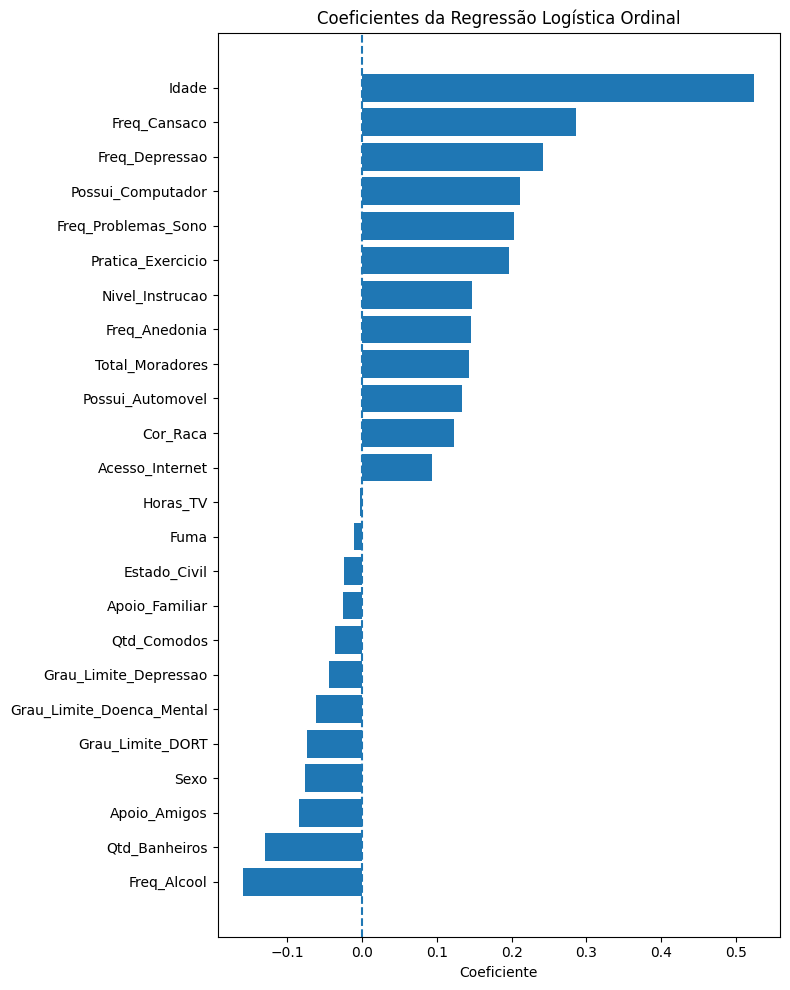

In [7]:
coef_plot = coef.sort_values("coef")

plt.figure(figsize=(8, 10))
plt.barh(coef_plot.index, coef_plot["coef"])
plt.axvline(0, linestyle="--")
plt.title("Coeficientes da Regressão Logística Ordinal")
plt.xlabel("Coeficiente")
plt.tight_layout()
plt.show()
